# Workshop 2: Quality Control (QC)
Preparing and filtering data for genome-wide association studies.

> Kostas Hatzikotoulas (hatzikotoulas@helmholtz-munich.de)

> Ana Arruda (ald73@cam.ac.uk; ana.luiza.arruda@mrc-epid.cam.ac.uk)

# Objectives

In this workshop, you will learn the data quality assessment and control steps that are typically carried out during genome wide association studies (GWAS).

## Prerequisites
For this practical workshop, we need the following software:
- [PLINK](https://www.cog-genomics.org/plink/) for data management
- [R](https://www.r-project.org/) for visualization of different QC measures



## Distinguish R Python and Bash Shells

> Since this a python configured notebook, we import the basic packages to integrate bash and R. Please make sure that you notice the following differences:

- when a command starts with `!`, this is a linux command writen in bash (for managing directories and executing plink commands)

- when a shell starts with `%%R` the code follows is written in R


## Why do we need the QC?

Study design and errors in genotype calling can introduce systematic biases into GWAS, leading to spurious associations. A thorough QC can help us identify samples and markers that should be removed prior to association analysis in order to minimize the number of false-positive and false-negative associations.

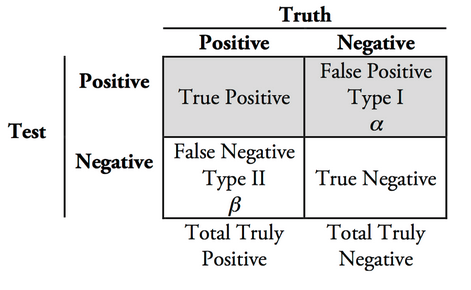

In this tutorial, we assume that the study design has been conducted appropriately and the QC applies to the genotypes after they have been called from probe intensity data.

QC protocol: The QC protocol of a GWAS is usually split into two broad categories, ***Sample QC*** and ***Variant QC***.

Sample QC is done prior to Variant QC because we want to maximise the number of markers remaining in the study.

## Sample QC

It consists of (at least) five steps:

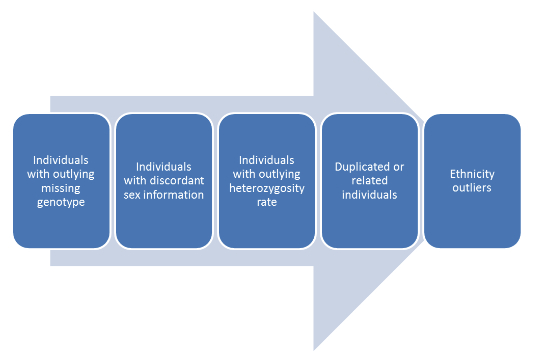

# Data, Directories & Libraries


## Google Drive

Let us set up the connection with Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We set up the file paths to the respective directories.

In [2]:
# this is the file path to your google drive (/content/drive/My Drive/) followed up by the data path
dir_path='/content/drive/My Drive/Complex_Traits/2_Workshop_Quality_Control/data/'
dir_scripts="/content/drive/My Drive/Complex_Traits/2_Workshop_Quality_Control/scripts/"


## Packages

Install the rpy2 package that allows us to run R from a python notebook

In [1]:
!pip install "numpy==1.26.4"
!pip install "pandas<2.0.0"
!pip install "rpy2==3.5.17"

  Using cached pandas-1.5.3.tar.gz (5.2 MB)
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 221.0/221.0 kB 8.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for rpy2: filename=rpy2-3.5.17-cp312-cp312-linux_x86_64.whl size=333353 sha256=7a4924e19cfdbd8d63469ee46a5b9a7880c23f83b84e3168e4516649ab779f90
  Stored in directory

Import necessary libraries. It might happen that during execution you get an error and are asked to "Restart" the session. Do so and execute the cell again - now everything should work!!!

In [4]:
import os # python related package to list files in the defined directory
import rpy2.ipython
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [5]:
%%R
dir_path = '/content/drive/My Drive/Complex_Traits/2_Workshop_Quality_Control/data'
setwd(paste0(dir_path))

In [6]:
%%bash
pwd

/content/drive/My Drive/Complex_Traits/2_Workshop_Quality_Control/data


Check the contents of the current path

In [7]:
%%bash
ls

VSS.bed
VSS.bim
VSS.fam


In [8]:
ls -lrt

total 68533
-rw------- 1 root root    13582 Jul 23  2021 VSS.fam
-rw------- 1 root root 12531474 Jul 23  2021 VSS.bim
-rw------- 1 root root 57631638 Jul 23  2021 VSS.bed


In [9]:

ls "/content/drive/My Drive/Complex_Traits/2_Workshop_Quality_Control/scripts"

calc_het_v2.pl  ExcludeIDsonIBD.r  space_to_tab.pl


## If Linux/Windows/Mac

If working on your local machine, or a remote server environment you will want to start any project by creating and defining your working directory in a variable name, such as:
```
mkdir your_directory_name
```
- where `your_directory_name` can be named as `QC`

```
DIR="path_to/your_directory_name"
```

- where `path_to` represents the directory until the folder we have just created
- `DIR` represents the variable where we store the complete path for the analysis (i.e `DIR=~/QC`)

In our case, we are using this notebook where no terminal is needed for execution of any commands, but there is a virtual directory for each user where we can download the data from github using `wget`, and run plink sofware with `!./plink`


## Downloading PLINK software

In [10]:
!wget https://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20210606.zip && unzip plink_linux_x86_64_20210606.zip && rm prettify toy.* LICENSE
!rm *.zip

--2026-05-20 08:15:25--  https://s3.amazonaws.com/plink1-assets/plink_linux_x86_64_20210606.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.60.40, 54.231.199.144, 16.15.237.125, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.60.40|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8917076 (8.5M) [application/zip]
Saving to: ‘plink_linux_x86_64_20210606.zip’

plink_linux_x86_64_ 100%[===================>]   8.50M  16.3MB/s    in 0.5s    

2026-05-20 08:15:26 (16.3 MB/s) - ‘plink_linux_x86_64_20210606.zip’ saved [8917076/8917076]

Archive:  plink_linux_x86_64_20210606.zip
  inflating: plink                   
  inflating: LICENSE                 
  inflating: toy.ped                 
  inflating: toy.map                 
  inflating: prettify                


- Quickly test that plink sofware command is executable on bash
> you should be able to see all available flags (options) plink has for data processing.

In [11]:
!./plink

PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3

  plink <input flag(s)...> [command flag(s)...] [other flag(s)...]
  plink --help [flag name(s)...]

Commands include --make-bed, --recode, --flip-scan, --merge-list,
--write-snplist, --list-duplicate-vars, --freqx, --missing, --test-mishap,
--hardy, --mendel, --ibc, --impute-sex, --indep-pairphase, --r2, --show-tags,
--blocks, --distance, --genome, --homozyg, --make-rel, --make-grm-gz,
--rel-cutoff, --cluster, --pca, --neighbour, --ibs-test, --regress-distance,
--model, --bd, --gxe, --logistic, --dosage, --lasso, --test-missing,
--make-perm-pheno, --tdt, --qfam, --annotate, --clump, --gene-report,
--meta-analysis, --epistasis, --fast-epistasis, and --score.

"plink --help | more" describes all functions (warning: long).


## Basic Plink Commands

### Step 1: Remove Individuals with outlying missing genotype

In [ ]:
# ignore this cell, can be used only if you cannot download the data and the drive ~ if connection is not working
#!wget -O data 'GitHub web link"

In [12]:
# define th file we will be working on:
FILE="VSS"

In [13]:
# 1.1 Generate a list genotyping/missingness rate statistics
!./plink --bfile $FILE --missing --out $FILE-missing

PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-missing.log.
Options in effect:
  --bfile VSS
  --missing
  --out VSS-missing

12975 MB RAM detected; reserving 6487 MB for main workspace.
426901 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%66%67%68%69%70%71%72%73%74%75%

In [14]:
# 1.2 Produce a log file giving samples excluded at Call Rate 0.98 to check against R result

# removing individuals with high missing genotype rates

!./plink --bfile $FILE --mind 0.02 --make-bed --out $FILE-mind0.02


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-mind0.02.log.
Options in effect:
  --bfile VSS
  --make-bed
  --mind 0.02
  --out VSS-mind0.02

12975 MB RAM detected; reserving 6487 MB for main workspace.
426901 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
14 people removed due to missing genotype data (--mind).
IDs written to VSS-mind0.02.irem .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 524 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%

### Step 2: Individuals with discordant sex information

In [15]:
# 2.1 Run sex checking

# use !./plink to run sex check and export your cleaned file as $FILE-sexcheck



In [16]:
#@title solution
# 2.1 Run sex checking

!./plink --bfile $FILE --check-sex --out $FILE-sexcheck


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-sexcheck.log.
Options in effect:
  --bfile VSS
  --check-sex
  --out VSS-sexcheck

12975 MB RAM detected; reserving 6487 MB for main workspace.
426901 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%66%67%68%69%70%71%72%73%74%7

In [17]:
# 2.2 Extract xchr SNPs

# use !./plink to Extract xchr SNPs and export your cleaned file as $FILE-xchr




In [18]:
#@title Solution
# 2.2 Extract xchr SNPs

!./plink --bfile $FILE --chr 23 --make-bed --out $FILE-xchr


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-xchr.log.
Options in effect:
  --bfile VSS
  --chr 23
  --make-bed
  --out VSS-xchr

12975 MB RAM detected; reserving 6487 MB for main workspace.
10465 out of 426901 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%66%67%68%69%70%71%72%

In [19]:
!ls -lrt

total 197104
-rwx------ 1 root root 41656224 Jun  6  2021 plink
-rw------- 1 root root    13582 Jul 23  2021 VSS.fam
-rw------- 1 root root 12531474 Jul 23  2021 VSS.bim
-rw------- 1 root root 57631638 Jul 23  2021 VSS.bed
-rw------- 1 root root      915 May 20 08:19 VSS-missing.log
-rw------- 1 root root 19637492 May 20 08:19 VSS-missing.lmiss
-rw------- 1 root root    36081 May 20 08:19 VSS-missing.imiss
-rw------- 1 root root    19987 May 20 08:19 VSS-missing.hh
-rw------- 1 root root      348 May 20 08:19 VSS-mind0.02.irem
-rw------- 1 root root      963 May 20 08:19 VSS-mind0.02.log
-rw------- 1 root root    13108 May 20 08:19 VSS-mind0.02.fam
-rw------- 1 root root 12531474 May 20 08:19 VSS-mind0.02.bim
-rw------- 1 root root 55924034 May 20 08:19 VSS-mind0.02.bed
-rw------- 1 root root    43120 May 20 08:19 VSS-sexcheck.sexcheck
-rw------- 1 root root      981 May 20 08:19 VSS-sexcheck.log
-rw------- 1 root root    19987 May 20 08:19 VSS-sexcheck.hh
-rw------- 1 root root    199

In [20]:
# 2.3 Run missingness on xchr SNPs

# use !./plink to Run missingness on xchr SNPs and export your cleaned file as $FILE-xchr-missing




In [21]:
#@title Solution
# 2.3 Run missingness on xchr SNPs

!./plink --bfile $FILE-xchr --missing --out $FILE-xchr-missing
!ls -lrt | tail -5

PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-xchr-missing.log.
Options in effect:
  --bfile VSS-xchr
  --missing
  --out VSS-xchr-missing

12975 MB RAM detected; reserving 6487 MB for main workspace.
10465 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%66%67%68%69%70%71%72%73%

### Step_3: Individuals with outlying heterozygosity rate


In [22]:
# 3.1 Extract autosomal SNPs

# use !./plink to Extract autosomal SNPs from $FILE and export your cleaned file as $FILE-chr1-22



In [23]:
#@title Solution
# 3.1 Extract autosomal SNPs

!./plink --bfile $FILE --autosome --make-bed --out $FILE-chr1-22
!ls -lrt | tail -5

PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-chr1-22.log.
Options in effect:
  --autosome
  --bfile VSS
  --make-bed
  --out VSS-chr1-22

12975 MB RAM detected; reserving 6487 MB for main workspace.
416436 out of 426901 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%66%67%68%69%70%7

In [24]:
# 3.2 Extract SNPs with minor allele frequency (MAF) greater than/equal to 1%

# use !./plink to Extract SNPs with minor allele frequency (MAF) greater than/equal to 1%
# from $FILE-chr1-22 and export your cleaned file as $FILE-chr1-22-mafgte0.01




In [25]:
#@title Solution
# 3.2 Extract SNPs with minor allele frequency (MAF) greater than/equal to 1%

!./plink --bfile $FILE-chr1-22 --maf 0.01 --make-bed --out $FILE-chr1-22-mafgte0.01


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-chr1-22-mafgte0.01.log.
Options in effect:
  --bfile VSS-chr1-22
  --maf 0.01
  --make-bed
  --out VSS-chr1-22-mafgte0.01

12975 MB RAM detected; reserving 6487 MB for main workspace.
416436 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%66%67%68%

In [26]:
# 3.3 Extract SNPs with MAF less than 1%
# use !./plink to  Extract SNPs with MAF less than 1% (input file $FILE-chr1-22)
# and export your cleaned file as $FILE-chr1-22-mafless0.01




In [27]:
#@title Solution
# 3.3 Extract SNPs with MAF less than 1%

!./plink --bfile $FILE-chr1-22 --exclude $FILE-chr1-22-mafgte0.01.bim --make-bed --out $FILE-chr1-22-mafless0.01


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-chr1-22-mafless0.01.log.
Options in effect:
  --bfile VSS-chr1-22
  --exclude VSS-chr1-22-mafgte0.01.bim
  --make-bed
  --out VSS-chr1-22-mafless0.01

12975 MB RAM detected; reserving 6487 MB for main workspace.
416436 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
--exclude: 139885 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%

In [28]:
# 3.4 Get missingness to plot against het in R

!./plink --bfile $FILE-chr1-22-mafless0.01 --missing --out  $FILE-chr1-22-mafless0.01-missing
!./plink --bfile $FILE-chr1-22-mafgte0.01 --missing --out  $FILE-chr1-22-mafgte0.01-missing


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-chr1-22-mafless0.01-missing.log.
Options in effect:
  --bfile VSS-chr1-22-mafless0.01
  --missing
  --out VSS-chr1-22-mafless0.01-missing

12975 MB RAM detected; reserving 6487 MB for main workspace.
139885 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%

In [29]:
# 3.4 Convert both to ped/map files in order to run the heterozygosity’s script

!./plink --bfile $FILE-chr1-22-mafless0.01 --recode --out $FILE-chr1-22-mafless0.01-recode
!./plink --bfile $FILE-chr1-22-mafgte0.01 --recode --out $FILE-chr1-22-mafgte0.01-recode



PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-chr1-22-mafless0.01-recode.log.
Options in effect:
  --bfile VSS-chr1-22-mafless0.01
  --out VSS-chr1-22-mafless0.01-recode
  --recode

12975 MB RAM detected; reserving 6487 MB for main workspace.
139885 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%64%65%66

In [30]:
# 3.5 Run heterozygosity’s script: (needs a few minutes)
# Tip: we call the calc_to_het.pl from one folder up

!perl ../scripts/calc_het_v2.pl -f $FILE-chr1-22-mafless0.01-recode


In [31]:
!perl ../scripts/calc_het_v2.pl -f $FILE-chr1-22-mafgte0.01-recode.ped


### We have created a file, called `Summary-VSS-chr1-22-mafless0.01-recode.ped`, which looks like this:

| ID          | total  | num_hom | num_het | Percent_hom | Percent_het |
|-------------|--------|---------|---------|-------------|-------------|
| BadSample_6 | 135535 | 135351  | 184     | 99.86       | 0.14        |
| BadSample_7 | 134619 | 134117  | 502     | 99.63       | 0.37        |
| BadSample_8 | 133015 | 132628  | 387     | 99.71       | 0.29        |
| BadSample_9 | 126921 | 126223  | 698     | 99.45       | 0.55        |
....

### Step 4: Indentify and remove duplicated or related individuals

>Relatedness/Duplicates

> Pair-wise IBD to look at duplicates.

> Using only variants ≥1%, excluding complex regions and LD prune using R-squared 0.2.

In [33]:
# 4.1 Exclude complex regions

# use !./plink to Exclude complex regions (complex.regions.txt) and export the cleaned file as $FILE-chr1-22-mafgte0.01-noCR




In [37]:
#@title Solution
# 4.1 Exclude complex regions

!./plink --bfile $FILE-chr1-22-mafgte0.01 --exclude complex_regions.txt --range --make-bed --out $FILE-chr1-22-mafgte0.01-noCR


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-chr1-22-mafgte0.01-noCR.log.
Options in effect:
  --bfile VSS-chr1-22-mafgte0.01
  --exclude complex_regions.txt
  --make-bed
  --out VSS-chr1-22-mafgte0.01-noCR
  --range

Note: --range flag deprecated.  Use e.g. "--extract range <filename>".
12975 MB RAM detected; reserving 6487 MB for main workspace.
276551 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
--exclude range: 9409 variants excluded.
--exclude range: 267142 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%3

In [38]:
# 4.2.1 LD prunning --> 2 steps

# pairwise genotypic correlation:

#1/2
!./plink --bfile $FILE-chr1-22-mafgte0.01-noCR --indep 50 5 1.25 --out $FILE-chr1-22-mafgte0.01-noCR-pruning


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-chr1-22-mafgte0.01-noCR-pruning.log.
Options in effect:
  --bfile VSS-chr1-22-mafgte0.01-noCR
  --indep 50 5 1.25
  --out VSS-chr1-22-mafgte0.01-noCR-pruning

12975 MB RAM detected; reserving 6487 MB for main workspace.
267142 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%

In [39]:
# 4.2.2 LD prunning

#2/2

!./plink --bfile $FILE-chr1-22-mafgte0.01-noCR --extract $FILE-chr1-22-mafgte0.01-noCR-pruning.prune.in --make-bed --out $FILE-chr1-22-mafgte0.01-noCR-LDpruned0.2


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-chr1-22-mafgte0.01-noCR-LDpruned0.2.log.
Options in effect:
  --bfile VSS-chr1-22-mafgte0.01-noCR
  --extract VSS-chr1-22-mafgte0.01-noCR-pruning.prune.in
  --make-bed
  --out VSS-chr1-22-mafgte0.01-noCR-LDpruned0.2

12975 MB RAM detected; reserving 6487 MB for main workspace.
267142 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
--extract: 60605 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%

In [40]:
# 4.3 Pair-wise IBD

!./plink --bfile $FILE-chr1-22-mafgte0.01-noCR-LDpruned0.2 --genome --out $FILE-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.log.
Options in effect:
  --bfile VSS-chr1-22-mafgte0.01-noCR-LDpruned0.2
  --genome
  --out VSS-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome

12975 MB RAM detected; reserving 6487 MB for main workspace.
60605 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
Using up to 2 threads (change this with --threads).
Before main variant filters, 538 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%5

In [41]:
# 4.4 Run space_to_tab.pl on the genome result:

!perl ../scripts/space_to_tab.pl $FILE-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.genome


### Step_5:  Ethnicity outliers: MDS distance matrix

For this step, you will need to merge your data with 1000 Genomes genotype data (we did this step for you and created th file2 named `VSS-1KG`)

In [42]:
FILE2="VSS-1Kg"

In [43]:
%%R
getwd()

[1] "/content/drive/MyDrive/Complex_Traits/2_Workshop_Quality_Control/data"


In [45]:
# 5.1 Pair-wise IBD: using only autosomal variants with MAF ≥1%, excluding complex regions.

!./plink --bfile $FILE2 --autosome --maf 0.01 --exclude complex_regions.txt --range --make-bed --out $FILE2-chr1-22-mafgte0.01-noCR


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-1Kg-chr1-22-mafgte0.01-noCR.log.
Options in effect:
  --autosome
  --bfile VSS-1Kg
  --exclude complex_regions.txt
  --maf 0.01
  --make-bed
  --out VSS-1Kg-chr1-22-mafgte0.01-noCR
  --range

Note: --range flag deprecated.  Use e.g. "--extract range <filename>".
12975 MB RAM detected; reserving 6487 MB for main workspace.
419253 out of 429718 variants loaded from .bim file.
1630 people (255 males, 283 females, 1092 ambiguous) loaded from .fam.
Ambiguous sex IDs written to VSS-1Kg-chr1-22-mafgte0.01-noCR.nosex .
--exclude range: 14597 variants excluded.
--exclude range: 404656 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 1630 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%

In [46]:
# 5.2 LD prune using R-squared 0.2.

!./plink --bfile $FILE2-chr1-22-mafgte0.01-noCR --indep 50 5 1.25 --out $FILE2-chr1-22-mafgte0.01-noCR-pruning
!./plink --bfile $FILE2-chr1-22-mafgte0.01-noCR --extract $FILE2-chr1-22-mafgte0.01-noCR-pruning.prune.in --make-bed --out $FILE2-chr1-22-mafgte0.01-noCR-LDpruned0.2


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-1Kg-chr1-22-mafgte0.01-noCR-pruning.log.
Options in effect:
  --bfile VSS-1Kg-chr1-22-mafgte0.01-noCR
  --indep 50 5 1.25
  --out VSS-1Kg-chr1-22-mafgte0.01-noCR-pruning

12975 MB RAM detected; reserving 6487 MB for main workspace.
279949 variants loaded from .bim file.
1630 people (255 males, 283 females, 1092 ambiguous) loaded from .fam.
Ambiguous sex IDs written to VSS-1Kg-chr1-22-mafgte0.01-noCR-pruning.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 1630 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%

In [47]:
# 5.3 Pair-wise IBD

!./plink --bfile $FILE2-chr1-22-mafgte0.01-noCR-LDpruned0.2 --genome --out $FILE2-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.log.
Options in effect:
  --bfile VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2
  --genome
  --out VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome

12975 MB RAM detected; reserving 6487 MB for main workspace.
65860 variants loaded from .bim file.
1630 people (255 males, 283 females, 1092 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.nosex .
Using up to 2 threads (change this with --threads).
Before main variant filters, 1630 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%

In [48]:

!perl ../scripts/space_to_tab.pl $FILE2-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.genome # space delimited to tab delimited script


In [49]:
# 5.4 MDS distance matrix calcualting the first 10 components

!./plink --bfile $FILE2-chr1-22-mafgte0.01-noCR-LDpruned0.2 --read-genome $FILE2-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.genome --cluster --mds-plot 10 --out $FILE2-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds.log.
Options in effect:
  --bfile VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2
  --cluster
  --mds-plot 10
  --out VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds
  --read-genome VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.genome

12975 MB RAM detected; reserving 6487 MB for main workspace.
65860 variants loaded from .bim file.
1630 people (255 males, 283 females, 1092 ambiguous) loaded from .fam.
Ambiguous sex IDs written to
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds.nosex .
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 1630 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%

## Investigate our results against R plots


In [50]:
%%R

# -----------------------------------------------------------------------------------------------------------------#
#         (1)  SAMPLE CALL RATE    - threshold = 98%                                                               #
# -----------------------------------------------------------------------------------------------------------------#

file <- "VSS" ; chip <- "Core Exome"; Cohort <- "VSS"

imiss <- read.table(paste0(file, "-missing.imiss"), header=T)
print(head(imiss)); print(dim(imiss))

           FID          IID MISS_PHENO N_MISS N_GENO  F_MISS
1  BadSample_6  BadSample_6          Y   8202 426901 0.01921
2  BadSample_7  BadSample_7          Y  15033 426901 0.03521
3  BadSample_8  BadSample_8          Y  14224 426901 0.03332
4  BadSample_9  BadSample_9          Y  30159 426901 0.07065
5 BadSample_10 BadSample_10          Y   9490 426901 0.02223
6  BadSample_1  BadSample_1          Y 234164 426901 0.54850
[1] 538   6


In [51]:
%%R
print(str(imiss))

'data.frame':	538 obs. of  6 variables:
 $ FID       : chr  "BadSample_6" "BadSample_7" "BadSample_8" "BadSample_9" ...
 $ IID       : chr  "BadSample_6" "BadSample_7" "BadSample_8" "BadSample_9" ...
 $ MISS_PHENO: chr  "Y" "Y" "Y" "Y" ...
 $ N_MISS    : int  8202 15033 14224 30159 9490 234164 105637 212529 94534 234100 ...
 $ N_GENO    : int  426901 426901 426901 426901 426901 426901 426901 426901 426901 426901 ...
 $ F_MISS    : num  0.0192 0.0352 0.0333 0.0707 0.0222 ...
NULL


In [52]:
%%R
print(summary(imiss$F_MISS))

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
1.640e-05 3.982e-05 4.685e-05 5.501e-03 5.388e-05 5.485e-01 


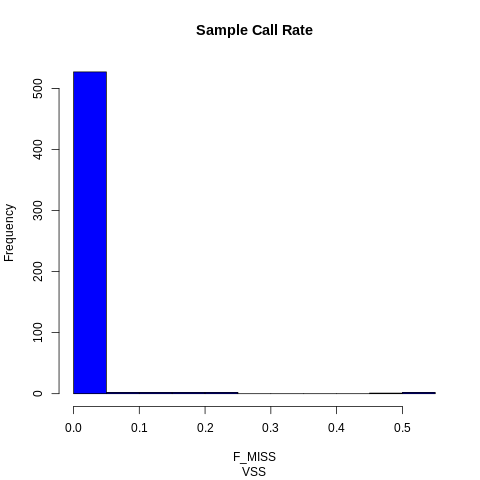

In [53]:
%%R
#plot data 1.1

hist(imiss$F_MISS,
     freq=TRUE,
     col="blue",
     border ="black",
     main = "Sample Call Rate",
     sub = Cohort,
     xlab="F_MISS",
     ylab="Frequency")

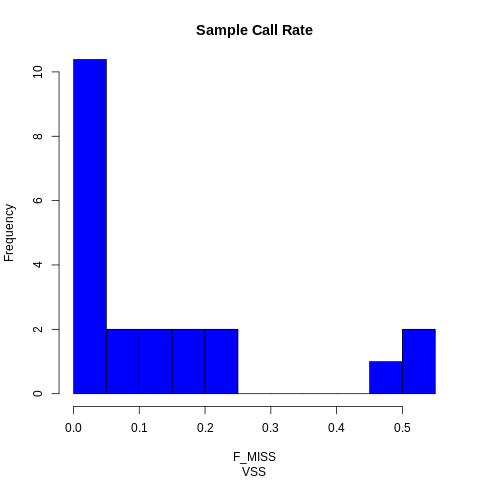

In [54]:
%%R
#plot data 1.2 - with altered axis
hist(imiss$F_MISS,
     freq=TRUE,
     col="blue",
     border ="black",
     main = "Sample Call Rate",
     sub = Cohort,
     xlab="F_MISS",
     ylab="Frequency",
     ylim = c(0, 10))


Samples to be removed at less than 98% call Rate

In [55]:
%%R

cr <- which(imiss$F_MISS > 0.02)  #98% call rate
# print(length(cr))

CR <- imiss[cr,]
crnumber <- dim(CR)[1]
write.table(CR, paste0(crnumber, "_", Cohort, "_", "_callrate_fails.txt"), sep="\t", col.names=TRUE, row.names=FALSE, quote=FALSE)

print(paste0("File ...", paste0(crnumber, "_", Cohort, "_", "_callrate_fail.txt"), ".. has been successfully saved"))

[1] "File ...14_VSS__callrate_fail.txt.. has been successfully saved"


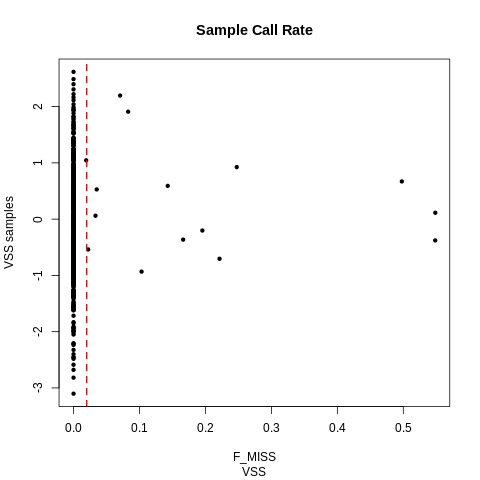

In [56]:
%%R
#Q: Can you try to plot the right number of excluded samples?
#1
hist(imiss$F_MISS,
     freq=TRUE,
     col="blue",
     border ="black",
     main = "Sample Call Rate",
     sub = Cohort,
     xlab="F_MISS",
     ylab="Frequency",
     ylim = c(0, 10),
     breaks=100)

abline(v=0.02, lwd=2, col="firebrick", lty=2)


#2
plot(sort(imiss$F_MISS),
     pch=20,
     main = "Sample Call Rate",
     xlab="VSS samples",
     ylab="F_MISS",)

abline(h=0.02, lwd=2, col="firebrick", lty=2)

#3
plot(y=rnorm(nrow(imiss)),
     x=imiss$F_MISS,
     pch=20,
     main = "Sample Call Rate",
     sub = Cohort,
     xlab="F_MISS",
     ylab="VSS samples")
abline(v=0.02, lwd=2, col="firebrick", lty=2)

In [57]:
!ls #see which files are stored in your directory

14_VSS__callrate_fails.txt
complex_regions.txt
plink
plink.log
Summary-VSS-chr1-22-mafgte0.01-recode.ped
Summary-VSS-chr1-22-mafless0.01-recode.ped
tab-VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.genome
tab-VSS-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.genome
VSS-1Kg.bed
VSS-1Kg.bim
VSS-1Kg-chr1-22-mafgte0.01-noCR.bed
VSS-1Kg-chr1-22-mafgte0.01-noCR.bim
VSS-1Kg-chr1-22-mafgte0.01-noCR.fam
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2.bed
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2.bim
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2.fam
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.genome
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome.log
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds.cluster1
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds.cluster2
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds.cluster3
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds.log
VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds.mds
VSS-1Kg-chr1-22-mafgte0.01-noCR-L

In [58]:
%%R
# -----------------------------------------------------------------------------------------------------------------#
#          (2) SEXCHECKING - load sexcheck file                                                                    #
# -----------------------------------------------------------------------------------------------------------------#

sexcheck <- read.table("VSS-sexcheck.sexcheck", header=TRUE, fill=TRUE)

print(paste0("Dimension of sexcheck dataframe is ")); print(dim(sexcheck))
print(" -------       -------       ------")
print(paste0("Columnames of sexcheck dataframe are ")); print(names(sexcheck))
print(" -------       -------       ------")
print(paste0("First rows of sexcheck dataframe are ")); print(head(sexcheck))


[1] "Dimension of sexcheck dataframe is "
[1] 538   6
[1] " -------       -------       ------"
[1] "Columnames of sexcheck dataframe are "
[1] "FID"    "IID"    "PEDSEX" "SNPSEX" "STATUS" "F"     
[1] " -------       -------       ------"
[1] "First rows of sexcheck dataframe are "
           FID          IID PEDSEX SNPSEX STATUS        F
1  BadSample_6  BadSample_6      2      2     OK  0.01742
2  BadSample_7  BadSample_7      1      1     OK  0.96310
3  BadSample_8  BadSample_8      2      2     OK -0.02153
4  BadSample_9  BadSample_9      2      2     OK  0.03834
5 BadSample_10 BadSample_10      2      2     OK -0.05174
6  BadSample_1  BadSample_1      2      2     OK -1.00500


In [59]:
%%R
# -----------------------------------------------------------------------------------------------------------------#
#          (2) SEXCHECKING: load -xchr-missing.imiss file                                                          #
# -----------------------------------------------------------------------------------------------------------------#

xchr_imiss<-read.table("VSS-xchr-missing.imiss", header=TRUE, fill=TRUE)

print(paste0("Dimension of xchr_imiss dataframe is ")); print(dim(xchr_imiss))
print(" -------       -------       ------")
print(paste0("Columnames of xchr_imiss dataframe are ")); print(names(xchr_imiss))
print(" -------       -------       ------")
print(paste0("First rows of xchr_imiss dataframe are ")); print(head(xchr_imiss))


[1] "Dimension of xchr_imiss dataframe is "
[1] 538   6
[1] " -------       -------       ------"
[1] "Columnames of xchr_imiss dataframe are "
[1] "FID"        "IID"        "MISS_PHENO" "N_MISS"     "N_GENO"    
[6] "F_MISS"    
[1] " -------       -------       ------"
[1] "First rows of xchr_imiss dataframe are "
           FID          IID MISS_PHENO N_MISS N_GENO   F_MISS
1  BadSample_6  BadSample_6          Y     98  10465 0.009365
2  BadSample_7  BadSample_7          Y    498  10465 0.047590
3  BadSample_8  BadSample_8          Y    292  10465 0.027900
4  BadSample_9  BadSample_9          Y    414  10465 0.039560
5 BadSample_10 BadSample_10          Y    203  10465 0.019400
6  BadSample_1  BadSample_1          Y   5454  10465 0.521200


In [60]:
%%R
# -----------------------------------------------------------------------------------------------------------------#
#          (2) SEXCHECKING : make a custom dataframe                                                               #
# -----------------------------------------------------------------------------------------------------------------#

sexcheck_imiss <- data.frame(FID=sexcheck$FID,
                             IID=sexcheck$IID,
                             PEDSEX=sexcheck$PEDSEX,
                             SNPSEX=sexcheck$SNPSEX,
                             STATUS=sexcheck$STATUS,
                             F_inbreed=sexcheck$F,
                             F_MISS=xchr_imiss$F_MISS)

print(names(sexcheck_imiss)); print(dim(sexcheck_imiss)); print(head(sexcheck_imiss))


[1] "FID"       "IID"       "PEDSEX"    "SNPSEX"    "STATUS"    "F_inbreed"
[7] "F_MISS"   
[1] 538   7
           FID          IID PEDSEX SNPSEX STATUS F_inbreed   F_MISS
1  BadSample_6  BadSample_6      2      2     OK   0.01742 0.009365
2  BadSample_7  BadSample_7      1      1     OK   0.96310 0.047590
3  BadSample_8  BadSample_8      2      2     OK  -0.02153 0.027900
4  BadSample_9  BadSample_9      2      2     OK   0.03834 0.039560
5 BadSample_10 BadSample_10      2      2     OK  -0.05174 0.019400
6  BadSample_1  BadSample_1      2      2     OK  -1.00500 0.521200


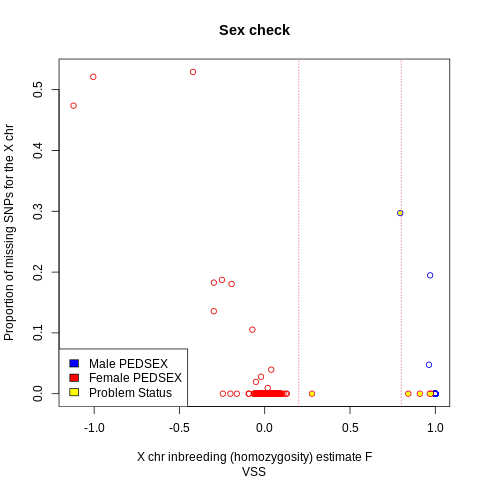

In [61]:
%%R
# -----------------------------------------------------------------------------------------------------------------#
#          (2) SEXCHECKING - plotting                                                                              #
# -----------------------------------------------------------------------------------------------------------------#

plot(sexcheck_imiss$F_inbreed,
     xchr_imiss$F_MISS,
     col="grey",
     main="Sex check",
     sub= Cohort,
     xlab="X chr inbreeding (homozygosity) estimate F",
     ylab="Proportion of missing SNPs for the X chr")

temp <- subset(sexcheck_imiss, sexcheck_imiss$PEDSEX=="1") #1=males
points(temp$F_inbreed, temp$F_MISS, col="Blue")

temp <- subset(sexcheck_imiss, sexcheck_imiss$PEDSEX=="2") #2=females
points(temp$F_inbreed, temp$F_MISS, col="Red")

temp <- subset(sexcheck_imiss, sexcheck_imiss$STATUS=="PROBLEM") #STATUS
points(temp$F_inbreed, temp$F_MISS, col="Yellow", pch=16,cex=0.8)

legend("bottomleft", c("Male PEDSEX","Female PEDSEX", "Problem Status"), fill=c("Blue","Red", "Yellow"))
abline(v=0.8,col=2,lty=3)
abline(v=0.2,col=2,lty=3)


In [62]:
%%R

# save the data with status=PROBLEM
sc <- which(sexcheck_imiss$STATUS=="PROBLEM")
SC <- sexcheck_imiss[sc,c(2,3,4,5,6,7)]
scnumber <- dim(SC)[1]
write.table(SC, paste0(Cohort, "_sexcheck_fails.txt"), sep="\t", col.names=TRUE, row.names=FALSE, quote=FALSE)

print(paste0(Cohort, "_sexcheck_fails.txt", ".. has been successfully saved", " ... ", "identifying ", scnumber, " problematic cases"))


[1] "VSS_sexcheck_fails.txt.. has been successfully saved ... identifying 6 problematic cases"


In [63]:
%%R

# -----------------------------------------------------------------------------------------------------------------#
#      (3)    Heterozygosity   MAF≥1% and MAF<1%                                                                   #
# -----------------------------------------------------------------------------------------------------------------#

Het<-read.table("Summary-VSS-chr1-22-mafgte0.01-recode.ped", header=TRUE, fill=TRUE)


In [64]:
%%R
Het[1:3,]

           ID  total num_hom num_het Percent_hom Percent_het
1 BadSample_6 272797  176653   96144       64.76       35.24
2 BadSample_7 267282  174912   92370       65.44       34.56
3 BadSample_8 269489  175109   94380       64.98       35.02


In [65]:
%%R

Aut_imiss<-read.table( "VSS-chr1-22-mafgte0.01-missing.imiss", header=TRUE, fill=TRUE)
Aut_imiss[1:3,]

          FID         IID MISS_PHENO N_MISS N_GENO  F_MISS
1 BadSample_6 BadSample_6          Y   3754 276551 0.01357
2 BadSample_7 BadSample_7          Y   9269 276551 0.03352
3 BadSample_8 BadSample_8          Y   7062 276551 0.02554


In [66]:
%%R
#merge the two dfs
names(Het)[1]="FID"
Het_Aut_imiss=merge(Het, Aut_imiss, by="FID")

In [67]:
%%R
Het_Aut_imiss[1:3,]

           FID  total num_hom num_het Percent_hom Percent_het          IID
1  BadSample_1 129719   56347   73372       43.44       56.56  BadSample_1
2 BadSample_10 271735  177546   94189       65.34       34.66 BadSample_10
3 BadSample_11 243654  148473   95181       60.94       39.06 BadSample_11
  MISS_PHENO N_MISS N_GENO  F_MISS
1          Y 146832 276551 0.53090
2          Y   4816 276551 0.01741
3          Y  32897 276551 0.11900


[1] 538   6
           FID  total num_hom num_het Percent_hom Percent_het
1  BadSample_6 272797  176653   96144       64.76       35.24
2  BadSample_7 267282  174912   92370       65.44       34.56
3  BadSample_8 269489  175109   94380       64.98       35.02
4  BadSample_9 259770  166977   92793       64.28       35.72
5 BadSample_10 271735  177546   94189       65.34       34.66
6  BadSample_1 129719   56347   73372       43.44       56.56


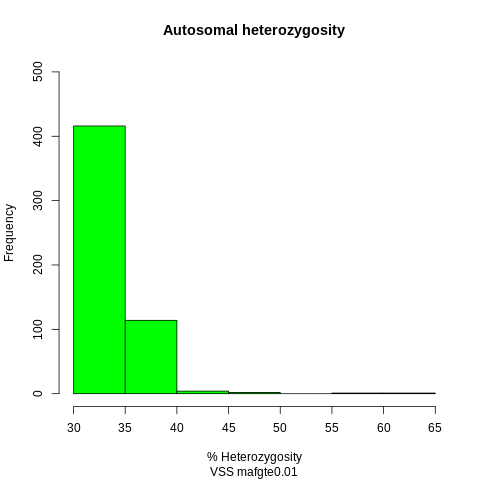

In [68]:
%%R
maf <- "mafgte0.01"
Cohort="VSS"

# -----------------------------------------------------------------------------------------------------------------#
#      (3)    Heterozygosity   MAF≥1% and MAF<1%                                                                   #
# -----------------------------------------------------------------------------------------------------------------#


print(dim(Het))
print(head(Het))


hist(Het$Percent_het,
     freq=TRUE,
     col="green",
     border ="black",
     main = "Autosomal heterozygosity",
     sub = paste(Cohort, maf, sep=" "),
     xlab="% Heterozygosity",
     ylab="Frequency",
     ylim= c(0,80))


hist(Het$Percent_het,
     freq=TRUE,
     col="green",
     border ="black",
     main = "Autosomal heterozygosity",
     sub = paste(Cohort, maf, sep=" "),
     xlab="% Heterozygosity",
     ylab="Frequency",
     ylim= c(0,500))




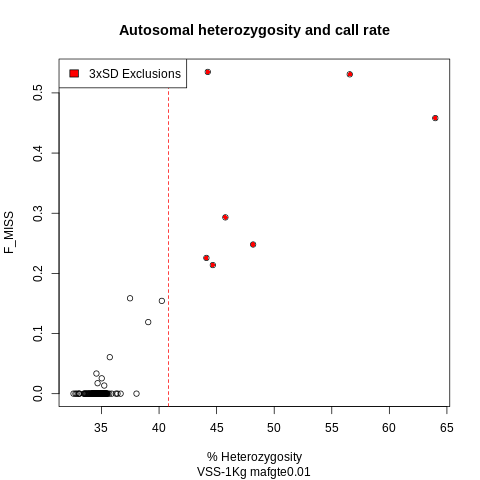

In [89]:
%%R

# -----------------------------------------------------------------------------------------------------------------#
#      (3)    Heterozygosity : Checking to see if any samples are more than 3xSD away from the mean.               #
# -----------------------------------------------------------------------------------------------------------------#

line1 <- mean(Het_Aut_imiss$Percent_het, na.rm=TRUE) - 3*sd(Het_Aut_imiss$Percent_het, na.rm=TRUE)
line2 <- mean(Het_Aut_imiss$Percent_het, na.rm=TRUE) + 3*sd(Het_Aut_imiss$Percent_het, na.rm=TRUE)

Exclu <- subset(
  Het_Aut_imiss,
  Percent_het < line1 | Percent_het > line2
)

plot(
  Het_Aut_imiss$Percent_het,
  Het_Aut_imiss$F_MISS,
  main = "Autosomal heterozygosity and call rate",
  sub = paste(Cohort, maf, sep=" "),
  xlab = "% Heterozygosity",
  ylab = "F_MISS"
)

abline(v=line1, col="red", lty=2)
abline(v=line2, col="red", lty=2)

points(
  Exclu$Percent_het,
  Exclu$F_MISS,
  col="red",
  pch=16,
  cex=0.8
)

legend("topleft", c("3xSD Exclusions"), fill="red")




In [90]:
%%R

# -----------------------------------------------------------------------------------------------------------------#
#      (3)    Heterozygosity : Saving the exclusions file#
# -----------------------------------------------------------------------------------------------------------------#


Aut_imiss[1:3,]
Het_Aut_imiss[1:10,]

write.table(Het_Aut_imiss,
            file="Het_Aut_imiss_mafgte001.txt",
            sep="\t", col.names=TRUE,
            row.names=FALSE,
            quote=FALSE)
#Please repeat the analysis for maf <1%

In [71]:
%%R

# -----------------------------------------------------------------------------------------------------------------#
#      (4)   DUPLICATES - RELATEDNESS
# -----------------------------------------------------------------------------------------------------------------#

maf <- "mafgte0.01"
Cohort <- "VSS"
r_file=paste0("tab-", Cohort, "-chr1-22-", maf, "-noCR-LDpruned0.2-genome.genome")
genome<-read.table(paste0(r_file), sep = "\t", header=TRUE, fill=TRUE)


> reminder for pi-hat values...

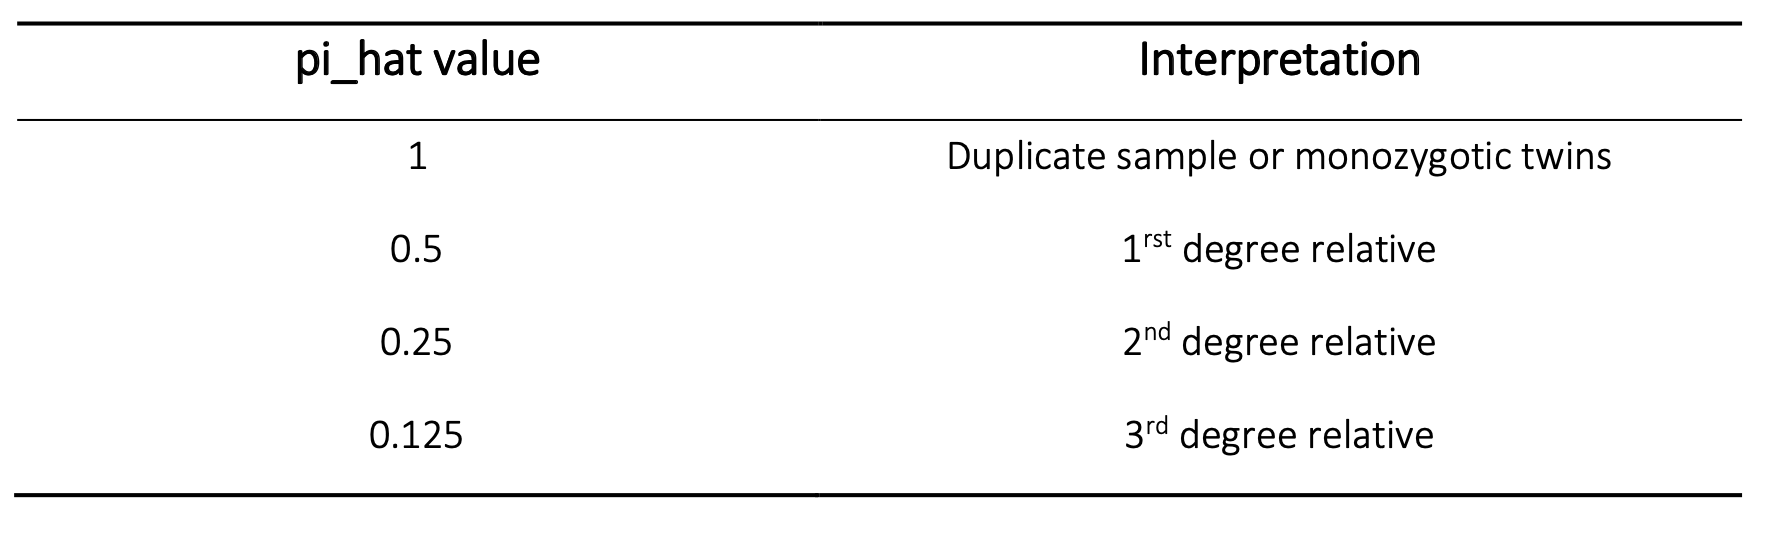

In [72]:
%%R
print(paste0("Dimesions of genome dataframe is .. ", dim(genome)[1], " rows and ", dim(genome)[2], " columns, having the following column names:")); names(genome)
print(genome[1:3,]); print(summary(genome$PI_HAT))


[1] "Dimesions of genome dataframe is .. 144453 rows and 14 columns, having the following column names:"
         FID1        IID1        FID2        IID2 RT EZ     Z0     Z1     Z2
1 BadSample_6 BadSample_6 BadSample_7 BadSample_7 UN NA 0.9632 0.0296 0.0072
2 BadSample_6 BadSample_6 BadSample_8 BadSample_8 UN NA 0.9783 0.0000 0.0217
3 BadSample_6 BadSample_6 BadSample_9 BadSample_9 UN NA 0.9588 0.0306 0.0106
  PI_HAT PHE      DST    PPC  RATIO
1 0.0220  -1 0.793214 0.9282 2.1214
2 0.0217  -1 0.792322 0.4684 1.9937
3 0.0259  -1 0.794018 0.9926 2.2087
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.00000 0.00000 0.00000 0.01366 0.01920 0.99160 


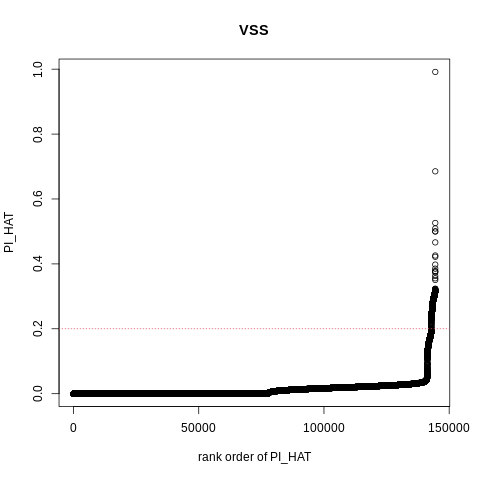

In [79]:
%%R
#Plotting the PIHATs in rank order

sorted_PI_HAT <- sort(genome$PI_HAT)
plot(sorted_PI_HAT, main= file, xlab= "rank order of PI_HAT", ylab = "PI_HAT")
abline(h=0.2,col=2,lty=3)


In [80]:
%%R

#subsetting out the duplicates (PH_HAT > 0.9)
w_PiHat_above_thresh <- which(genome$PI_HAT > 0.9)
print(length(w_PiHat_above_thresh));print(head(w_PiHat_above_thresh))

PiHat_above_thresh <- genome[w_PiHat_above_thresh,]
dupnumber <- dim(PiHat_above_thresh)[1]


[1] 1
[1] 6379


In [81]:
%%R

# With the duplicates excluded (PI_HAT>0.9) what is the range for the remaining comparisons?
PiHat_below_thresh <- genome[-w_PiHat_above_thresh,]

print(range(PiHat_below_thresh$PI_HAT)) # taking min and max values


[1] 0.0000 0.6852


In [82]:
%%R
#Numbering the duplicate pairs and writing the file out for excel:
PiHat_above_thresh$Dup <- (1:nrow(PiHat_above_thresh))

# export file
write.table(PiHat_above_thresh,
            file=paste0(dupnumber, "_", Cohort,  "_PI_HATmore0.9.txt"),
            sep="\t",
            col.names=TRUE,
            row.names=FALSE,
            quote=FALSE)


In [83]:
%%R
#subsetting out the duplicates (PH_HAT > 0.2)
wPiHat_more_point_two <- which(genome$PI_HAT > 0.2)

#print(length(wPiHat_more_point_two)); print(head(wPiHat_more_point_two))


PiHat_more_point_two <- genome[wPiHat_more_point_two,]
dupnumber <- dim(PiHat_more_point_two)[1]

PiHatless_more_point_two <- genome[-wPiHat_more_point_two,]
print(range(PiHatless_more_point_two$PI_HAT))

PiHat_more_point_two$Dup <- (1:nrow(PiHat_more_point_two))

# export file
write.table(PiHat_more_point_two,
            file=paste0(dupnumber, "_", Cohort,  "_PI_HAT_more_point_two"),
            sep="\t",
            col.names=T,
            row.names=F,
            quote=F)




[1] 0.0000 0.1995


## ETHNICITY - Merging with 1000 genomes file          

In [84]:
%%R
# -----------------------------------------------------------------------------------------------------------------#
#      (5)   ETHNICITY           Merged with 1000 genomes file                                                     #
# -----------------------------------------------------------------------------------------------------------------#

Cohort <- "VSS-1Kg"
r_file <- "VSS-1Kg-chr1-22-mafgte0.01-noCR-LDpruned0.2-genome-mds.mds"
genome <- read.table(paste(r_file), header=TRUE, fill=T)

print(genome[1:3,]); dim(genome) # 1630 individuals and 10 principal components (PCAs)

              FID             IID SOL         C1         C2        C3        C4
1 BadSample_1_vss BadSample_1_vss   0 -0.0434356 -0.0179919 0.0892524 0.3028320
2 BadSample_2_vss BadSample_2_vss   0  0.0256251 -0.0269090 0.0244347 0.0753707
3 BadSample_3_vss BadSample_3_vss   0 -0.0233034 -0.0254609 0.0729719 0.2440300
          C5           C6           C7           C8          C9          C10
1 0.01403290  0.000211676 -0.006103420  0.000149211  0.00152770 -0.000196193
2 0.00120041 -0.002583550  0.009672010  0.002104630  0.00168792 -0.001037960
3 0.01481730 -0.003012130 -0.000501484 -0.000988815 -0.00049926 -0.001739990
[1] 1630   13


In [86]:
%%R
# Read Reference dataset information

pop_info <- read.table(paste("Populationfile-1kg.txt", sep="/"),
                       sep="\t",
                       header=TRUE, fill=T)

# see what pop info has:
print(pop_info[1:3,]); table(pop_info$Population)

  Population      ID    Sex
1        GBR HG00096   male
2        GBR HG00097 female
3        GBR HG00098   male

ACB ASW CDX CEU CHB CHD CHS CLM FIN GBR GIH IBS JPT KHV LWK MKK MXL PEL PUR TSI 
102 112 100 186 162 129 153 111 101 104 117 150 131 122 122 232 108 105 123 117 
VSS YRI 
538 229 


In [87]:
%%R

# Merge the Reference Dataset with the real data:
genome_popinfo <- merge(genome, pop_info, by.x = "FID", by.y = "ID", all.x = TRUE)

print(genome_popinfo[1:3,])

# export the file
write.table(genome_popinfo,
            file="Genome_Popinfo.txt",
            sep="\t",
            col.names=T,
            row.names=F,
            quote=F)


               FID              IID SOL         C1         C2         C3
1  BadSample_1_vss  BadSample_1_vss   0 -0.0434356 -0.0179919 0.08925240
2 BadSample_10_vss BadSample_10_vss   0  0.0252760 -0.0221895 0.00399895
3 BadSample_11_vss BadSample_11_vss   0  0.0235952 -0.0219677 0.00633073
          C4          C5           C6          C7          C8          C9
1 0.30283200  0.01403290  0.000211676 -0.00610342 0.000149211 1.52770e-03
2 0.00217606 -0.00330442 -0.004094980  0.00826350 0.003480260 6.17523e-04
3 0.00709800 -0.00378897 -0.001308440  0.00501555 0.001593950 1.27507e-05
           C10 Population    Sex
1 -0.000196193        VSS female
2 -0.000356548        VSS female
3 -0.002524770        VSS   male


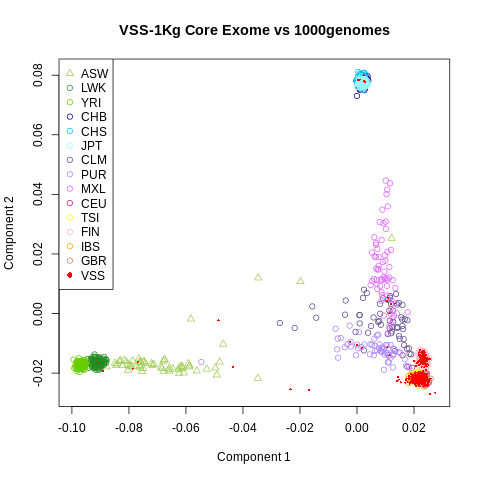

In [91]:
%%R
# -----------------------------------------------------------------------------------------------------------------#
#      (5)   ETHNICITY           Merged with 1000 genomes file: Plotting the                                       #
# -----------------------------------------------------------------------------------------------------------------#


Graph_title <- paste(Cohort,chip, "vs 1000genomes", sep=" ")

#Plotting C1 and C2 - subsetting by population

# that is the basic plot
plot(genome_popinfo$C1, genome_popinfo$C2, col="white", main= Graph_title , xlab="Component 1", ylab="Component 2") #change to white for plot


# these are the additional Layers adding on top one after the other:


temp <- subset(genome_popinfo, genome_popinfo$Population=="ASW") # HapMap African ancestry individuals from SW US
points(temp$C1, temp$C2, col="darkolivegreen3", pch=2)

temp <- subset(genome_popinfo, genome_popinfo$Population=="LWK") # (LWK) Luhya individuals
points(temp$C1, temp$C2, col="forestgreen")

temp <- subset(genome_popinfo, genome_popinfo$Population=="YRI") # (YRI) Yoruba individuals
points(temp$C1, temp$C2, col="chartreuse3")

temp <- subset(genome_popinfo, genome_popinfo$Population=="CHB") # (CHB) Han Chinese in Beijing
points(temp$C1, temp$C2, col="darkblue")

temp <- subset(genome_popinfo, genome_popinfo$Population=="CHS")# (CHS) Han Chinese South
points(temp$C1, temp$C2, col="deepskyblue")

temp <- subset(genome_popinfo, genome_popinfo$Population=="JPT")# JPT Japanese individuals
points(temp$C1, temp$C2, col="darkslategray1")

temp <- subset(genome_popinfo, genome_popinfo$Population=="CLM")# Colombian in Medellin, Colombia
points(temp$C1, temp$C2, col="mediumpurple4")

temp <- subset(genome_popinfo, genome_popinfo$Population=="PUR")# Puerto Rican in Puerto Rico
points(temp$C1, temp$C2, col="mediumpurple1")

temp <- subset(genome_popinfo, genome_popinfo$Population=="MXL")# HapMap Mexican individuals from LA California
points(temp$C1, temp$C2, col="mediumorchid1")

temp <- subset(genome_popinfo, genome_popinfo$Population=="CEU")# CEPH individuals
points(temp$C1, temp$C2, col="mediumvioletred")

temp <- subset(genome_popinfo, genome_popinfo$Population=="TSI")# Toscan individuals
points(temp$C1, temp$C2, col="yellow")

temp <- subset(genome_popinfo, genome_popinfo$Population=="FIN")# HapMap Finnish individuals from Finland
points(temp$C1, temp$C2, col="pink1")

temp <- subset(genome_popinfo, genome_popinfo$Population=="IBS")# Iberian populations in Spain
points(temp$C1, temp$C2, col="orange")

temp <- subset(genome_popinfo, genome_popinfo$Population=="GBR")# British individuals from England and Scotland (GBR)
points(temp$C1, temp$C2, col="lightsalmon3")

temp <- subset(genome_popinfo, genome_popinfo$Population=="VSS")#data = VSS samples
points(temp$C1, temp$C2, col="red", pch=16, cex=0.4)


legend("topleft", c("ASW","LWK","YRI","CHB","CHS","JPT","CLM","PUR","MXL","CEU","TSI","FIN","IBS","GBR","VSS"),
       pch=c(2,1,1,1,1,1,1,1,1,1,1,1,1,1,16),
       col=c("darkolivegreen3","forestgreen","chartreuse3","darkblue","deepskyblue","darkslategray1","mediumpurple4","mediumpurple1",
             "mediumorchid1","mediumvioletred","yellow","pink1","orange","lightsalmon3","red"))


In [ ]:
%%R

# ---------------------------------------------------------------------------------------------------------------------------#
#      TASK: Identify the outliers, remove them from the population file (Populationfile-1kg_rmoutliers.txt) and plot again  #
# ---------------------------------------------------------------------------------------------------------------------------#

# Tip: Can you do this by using this file  Populationfile-1kg_rmoutliers.txt



















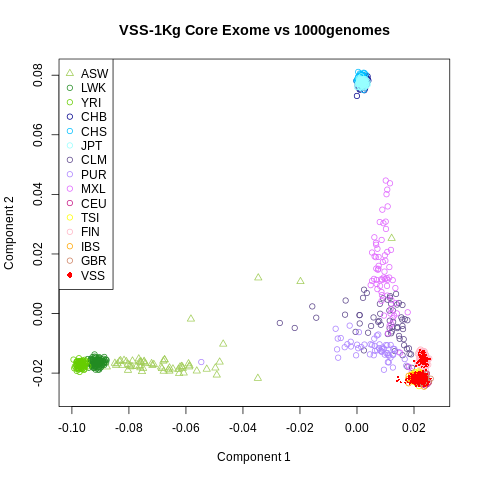

In [92]:
#@title Solution
%%R
# SOLUTION
pop_info <- read.table(paste("Populationfile-1kg_rmoutliers.txt", sep="/"), sep="\t", header=TRUE, fill=T)
genome_popinfo <- merge(genome, pop_info, by.x = "FID", by.y = "ID", all.x = TRUE)

plot(genome_popinfo$C1, genome_popinfo$C2, col="white", main= Graph_title , xlab="Component 1", ylab="Component 2") #change to white for plot
temp <- subset(genome_popinfo, genome_popinfo$Population=="ASW") # HapMap African ancestry individuals from SW US
points(temp$C1, temp$C2, col="darkolivegreen3", pch=2)
temp <- subset(genome_popinfo, genome_popinfo$Population=="LWK") # (LWK) Luhya individuals
points(temp$C1, temp$C2, col="forestgreen")
temp <- subset(genome_popinfo, genome_popinfo$Population=="YRI") # (YRI) Yoruba individuals
points(temp$C1, temp$C2, col="chartreuse3")
temp <- subset(genome_popinfo, genome_popinfo$Population=="CHB") # (CHB) Han Chinese in Beijing
points(temp$C1, temp$C2, col="darkblue")
temp <- subset(genome_popinfo, genome_popinfo$Population=="CHS")# (CHS) Han Chinese South
points(temp$C1, temp$C2, col="deepskyblue")
temp <- subset(genome_popinfo, genome_popinfo$Population=="JPT")# JPT Japanese individuals
points(temp$C1, temp$C2, col="darkslategray1")
temp <- subset(genome_popinfo, genome_popinfo$Population=="CLM")# Colombian in Medellin, Colombia
points(temp$C1, temp$C2, col="mediumpurple4")
temp <- subset(genome_popinfo, genome_popinfo$Population=="PUR")# Puerto Rican in Puerto Rico
points(temp$C1, temp$C2, col="mediumpurple1")
temp <- subset(genome_popinfo, genome_popinfo$Population=="MXL")# HapMap Mexican individuals from LA California
points(temp$C1, temp$C2, col="mediumorchid1")
temp <- subset(genome_popinfo, genome_popinfo$Population=="CEU")# CEPH individuals
points(temp$C1, temp$C2, col="mediumvioletred")
temp <- subset(genome_popinfo, genome_popinfo$Population=="TSI")# Toscan individuals
points(temp$C1, temp$C2, col="yellow")
temp <- subset(genome_popinfo, genome_popinfo$Population=="FIN")# HapMap Finnish individuals from Finland
points(temp$C1, temp$C2, col="pink1")
temp <- subset(genome_popinfo, genome_popinfo$Population=="IBS")# Iberian populations in Spain
points(temp$C1, temp$C2, col="orange")
temp <- subset(genome_popinfo, genome_popinfo$Population=="GBR")# British individuals from England and Scotland (GBR)
points(temp$C1, temp$C2, col="lightsalmon3")
temp <- subset(genome_popinfo, genome_popinfo$Population=="VSS")#data = VSS samples
points(temp$C1, temp$C2, col="red", pch=16, cex=0.4)
legend("topleft", c("ASW","LWK","YRI","CHB","CHS","JPT","CLM","PUR","MXL","CEU","TSI","FIN","IBS","GBR","VSS"), pch=c(2,1,1,1,1,1,1,1,1,1,1,1,1,1,16), col=c("darkolivegreen3","forestgreen","chartreuse3","darkblue","deepskyblue","darkslategray1","mediumpurple4","mediumpurple1","mediumorchid1","mediumvioletred","yellow","pink1","orange","lightsalmon3","red"))


In [94]:

# Last step: Combine all outliers' files and exclude them from your data

!./plink --bfile VSS --remove Final_exclusionlist.txt --make-bed --out VSS_sampleQCed


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS_sampleQCed.log.
Options in effect:
  --bfile VSS
  --make-bed
  --out VSS_sampleQCed
  --remove Final_exclusionlist.txt

12975 MB RAM detected; reserving 6487 MB for main workspace.
426901 variants loaded from .bim file.
538 people (255 males, 283 females) loaded from .fam.
--remove: 498 people remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 498 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48%49%50%51%52%53%54%55%56%57%58%59%60%61%62%63%

# Variant QC
Variant QC

It consists of (at least) four steps:

- Identification of variants with an excessive missing genotype
- Identification of variants demonstrating a significant deviation from Hardy-Weinberg equilibrium (HWE)
- Removal of all makers with a very low minor allele frequency
- Removal of all makers with cluster separation score $<0.4$


________________

The criteria used to filter out low quality markers differ from study to study Variant QC must be done with great care as every removed marker is potentially a missed disease variant Imputation can be used to recover some of the excluded markers

Here we are using the following thresholds:

> $Call \ Rate < 98$%


> $Hwe = p <=1x10-4$

> $MAF = 1$ %

> Cluster separation score $<=0.4$



In [ ]:
# ---------------------------------------------------------------------------------------------------------------------------#
#      TASK: Q: Can you run the plink command for all these thresholds:                                                      #
# ---------------------------------------------------------------------------------------------------------------------------#
# Tip: Samples with cluster seperation score<=0.4 are saved into a filename called cluster_sep_scr_to-exclude.txt





In [97]:
#@title Solution

!./plink --bfile VSS_sampleQCed --geno 0.02 --hwe 0.0001 --exclude cluster_sep_scr_to-exclude.txt --maf 0.01 --make-bed --out VSS_sampleQCed_variantQCed


PLINK v1.90b6.24 64-bit (6 Jun 2021)           www.cog-genomics.org/plink/1.9/
(C) 2005-2021 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to VSS_sampleQCed_variantQCed.log.
Options in effect:
  --bfile VSS_sampleQCed
  --exclude cluster_sep_scr_to-exclude.txt
  --geno 0.02
  --hwe 0.0001
  --maf 0.01
  --make-bed
  --out VSS_sampleQCed_variantQCed

12975 MB RAM detected; reserving 6487 MB for main workspace.
426901 variants loaded from .bim file.
498 people (240 males, 258 females) loaded from .fam.
--exclude: 425864 variants remaining.
Using 1 thread (no multithreaded calculations invoked).
Before main variant filters, 498 founders and 0 nonfounders present.
Calculating allele frequencies... 0%1%2%3%4%5%6%7%8%9%10%11%12%13%14%15%16%17%18%19%20%21%22%23%24%25%26%27%28%29%30%31%32%33%34%35%36%37%38%39%40%41%42%43%44%45%46%47%48

## Resources & References:

- [Genome-wide association studies](https://www.nature.com/articles/s43586-021-00056-9)
- [Data quality control in genetic case-control association studies](https://www.nature.com/articles/nprot.2010.116)
- [A tutorial on conducting genome‐wide association studies: Quality control and statistical analysis](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6001694/)

- [The International HapMap Project](https://pubmed.ncbi.nlm.nih.gov/14685227/)

- [An integrated map of genetic variation from 1,092 human genomes](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3498066/)


- [Genomics Boot Camp](https://genomicsbootcamp.github.io/book/)
